In [1]:
import json
import os
import torch
import torch.nn as nn
from torch_geometric import seed_everything
import pandas as pd
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

from src.augmentation import Aug
from src.model import get_model
from src.datasets import DataSplit, get_evaluator, full_eval
from src.predictor import get_predictor
from src.train import pretrain, pred_train, baseline_train, test, get_loss
from src.utils import store_res, compute_table, full_output

DATASETS = ["synthetic_1", "synthetic_2", "synthetic_3"]
MODELS = ["baseline", "grace", "lgrace", 'lnewgrace', "agrace", "extagrace", "a2grace", "bgrl", "extabgrl", "a2bgrl", "abgrl"]
AUGMENTATIONS = ["random", "scom", "sbm", "sbm2"]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:155: SyntaxWarning: invalid escape sequence '\{'
  """
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:272: SyntaxWarning: invalid escape sequence '\{'
  """
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:296: SyntaxWarning: invalid escape sequence '\{'
  """
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:319: SyntaxWarning: invalid escape sequence '\{'
  """
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:343: SyntaxWarning: invalid escape sequence '\{'
  """
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:663: SyntaxWarning: invalid escape sequence '\s'
  """Average embeddedness of nodes within the community.
/home/jovyan/envs/p312/lib/python3.12/site-packages/cdlib/classes/node_clustering.py:961: SyntaxWarning: inva

ImportError: /home/jovyan/envs/p312/lib/python3.12/site-packages/torch/lib/libgomp-a34b3233.so.1: version `GOMP_5.0' not found (required by /home/jovyan/envs/p312/lib/python3.12/site-packages/graph_tool/libgraph_tool_core.so)

In [ ]:
def hp_load(dataset: str):
    print(f"....{dataset}....")
    if "synthetic" in dataset:
        hp_files = os.path.join('params','synthetic.json')
    else:
        hp_files = os.path.join('params', dataset+'.json')
    with open(hp_files) as json_file:
        hp = json.load(json_file)
        hp["model"]["epochs"] = 100
        hp["model"]["ct_epochs"] = 500
        hp["model"]["use_valedges_as_input"] = True
    return hp

def visu_tsne(h, partition):
    tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
    h = h.cpu()
    tsne_results = tsne.fit_transform(h)
    df = pd.DataFrame()    
    df['tsne-2d-one'] = tsne_results[:,0]
    df['tsne-2d-two'] = tsne_results[:,1]
    labels = [-1] * len(df)
    for group_id, group_nodes in enumerate(partition):
        for node in group_nodes:
            if node < len(labels):
                labels[node] = group_id
            else:
                print(f"index {node} doesn't exist in h.")
    df['group'] = labels
    markers_list = ['o', 's', 'D', 'v', '^', '<', '>', 'P', 'X', '*']
    df['marker'] = df['group'].apply(lambda g: markers_list[g % 10] if g >= 0 else 'o')
    plt.figure(figsize=(16,10))
    sns.scatterplot(
        x="tsne-2d-one", y="tsne-2d-two",
        hue="group",
        style="marker",
        palette=sns.color_palette("hls", len(partition)),
        data=df,
        legend="full",
        alpha=0.5
    )

# RANDOM vs scom vs SBM vs SBM2

In [ ]:
def simple_run(model_name, augmentation_name, datasets):
    seed_everything(1)
    for dataset in datasets:
        hp = hp_load(dataset)
        data_split = DataSplit(dataset, device, 1, True, False, False)
        evaluator = get_evaluator(dataset)
        data, split_edge = data_split.get(0)
        model = get_model(model_name, data, hp['model'])
        predictor = get_predictor("mlp", hp['model'])
        aug = Aug(data, hp['augmentation'], augmentation_name)
        pre_time = pretrain(model_name, model, aug, hp['model'])
        print(data.partition)
        visu_tsne(model(data.x, data.edge_index).cpu().detach(), data.partition)
        if isinstance(predictor, nn.Module):
            predictor = predictor.to(device)
            pred_train(model, predictor, data, split_edge, 'log_sig', hp['model'])
        pos_valid_pred, neg_valid_pred, pos_test_pred, neg_test_pred = test(model, predictor, data, split_edge, hp['model'])
        val_res = full_eval(evaluator, pos_valid_pred, neg_valid_pred)
        test_res = full_eval(evaluator, pos_test_pred, neg_test_pred)
        for (key, v_res), t_res in zip(val_res.items(), test_res.values()):
            print(f"{key}:  val: {100 * v_res:.2f}%, test: {100 * t_res:.2f}%")

In [ ]:
# grace random
model_name = "grace"
augmentation_name = "random"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 14.90it/s]


split time:  0.07  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


100%|██████████| 500/500 [00:10<00:00, 46.57it/s]


pretrain loss:  [6.73, 6.71, 6.71, 6.71, 6.71]
pretrain time: 10.74 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.112s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.803338
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.473038
[t-SNE] KL divergence after 300 iterations: 1.583356


100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


train loss:  [0.31, 0.24, 0.21, 0.2, 0.19, 0.18, 0.17, 0.17, 0.16, 0.16]
train time: 63.15 s
Hits@10:  val: 24.18%, test: 26.20%
Hits@20:  val: 40.98%, test: 34.60%
Hits@50:  val: 53.07%, test: 49.95%
Hits@100:  val: 63.52%, test: 59.16%
ROCAUC:  val: 76.96%, test: 81.99%
AP:  val: 80.24%, test: 84.34%


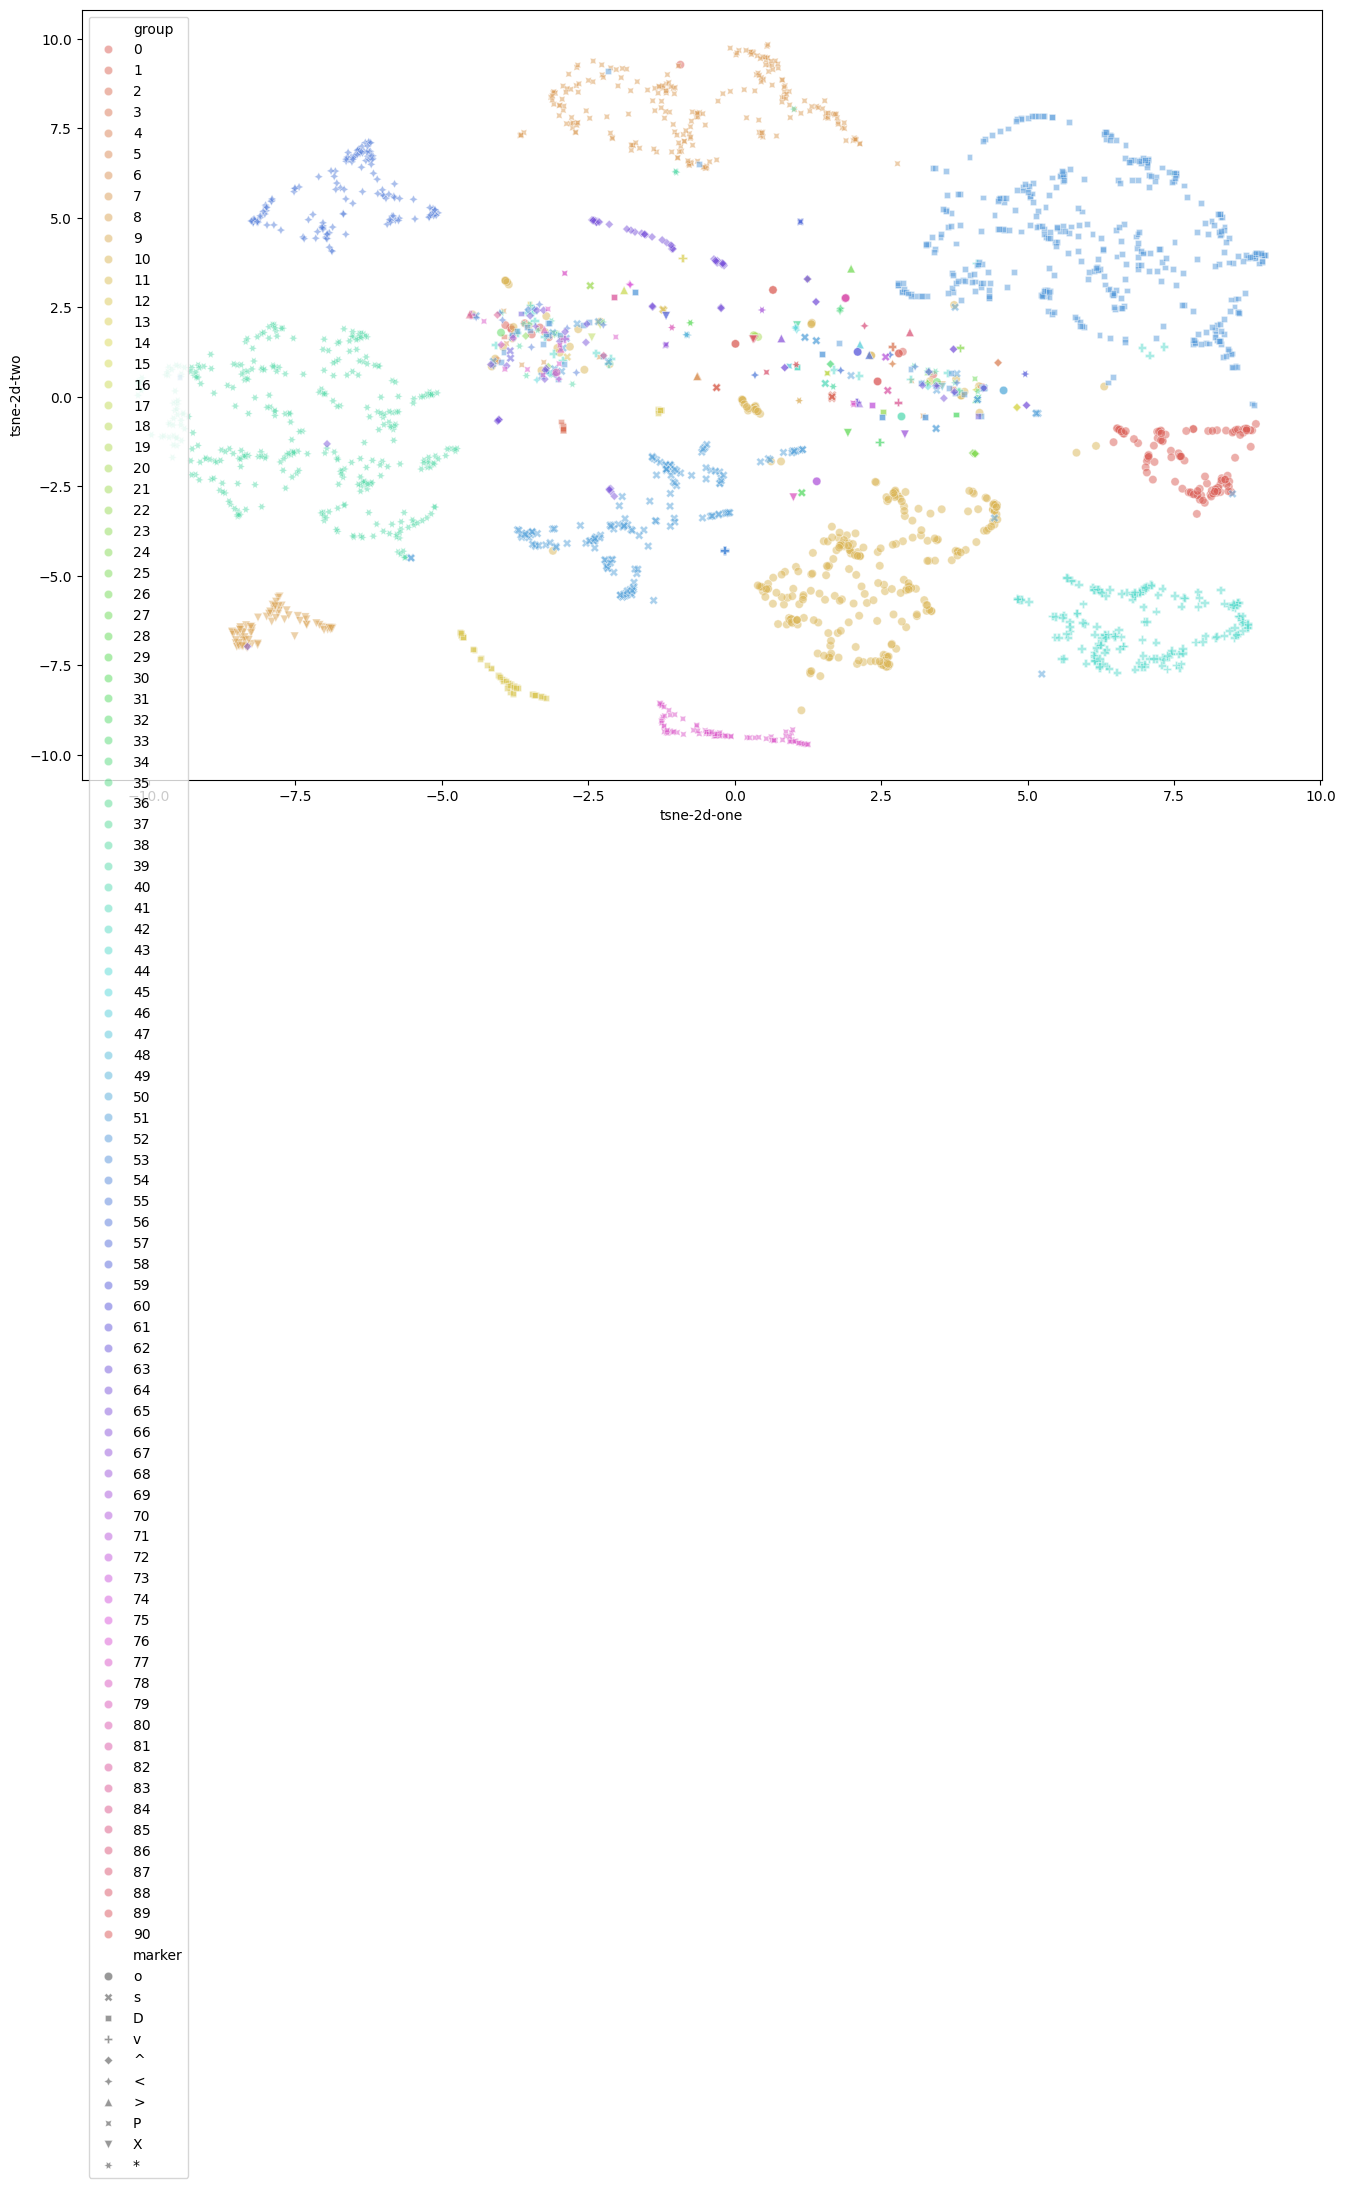

In [53]:
# grace scom
model_name = "grace"
augmentation_name = "scom"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 14.33it/s]


split time:  0.07  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976
already communities


100%|██████████| 500/500 [04:09<00:00,  2.01it/s]


pretrain loss:  [6.95, 6.93, 6.93, 6.92, 6.92]
pretrain time: 249.05 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.098s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.790497
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.014256
[t-SNE] KL divergence after 300 iterations: 1.251276


100%|██████████| 100/100 [01:03<00:00,  1.57it/s]


train loss:  [0.58, 0.52, 0.48, 0.46, 0.44, 0.43, 0.42, 0.41, 0.41, 0.4]
train time: 63.85 s
Hits@10:  val: 27.66%, test: 25.69%
Hits@20:  val: 36.68%, test: 38.59%
Hits@50:  val: 92.01%, test: 71.65%
Hits@100:  val: 98.16%, test: 97.44%
ROCAUC:  val: 94.03%, test: 95.74%
AP:  val: 92.00%, test: 93.94%


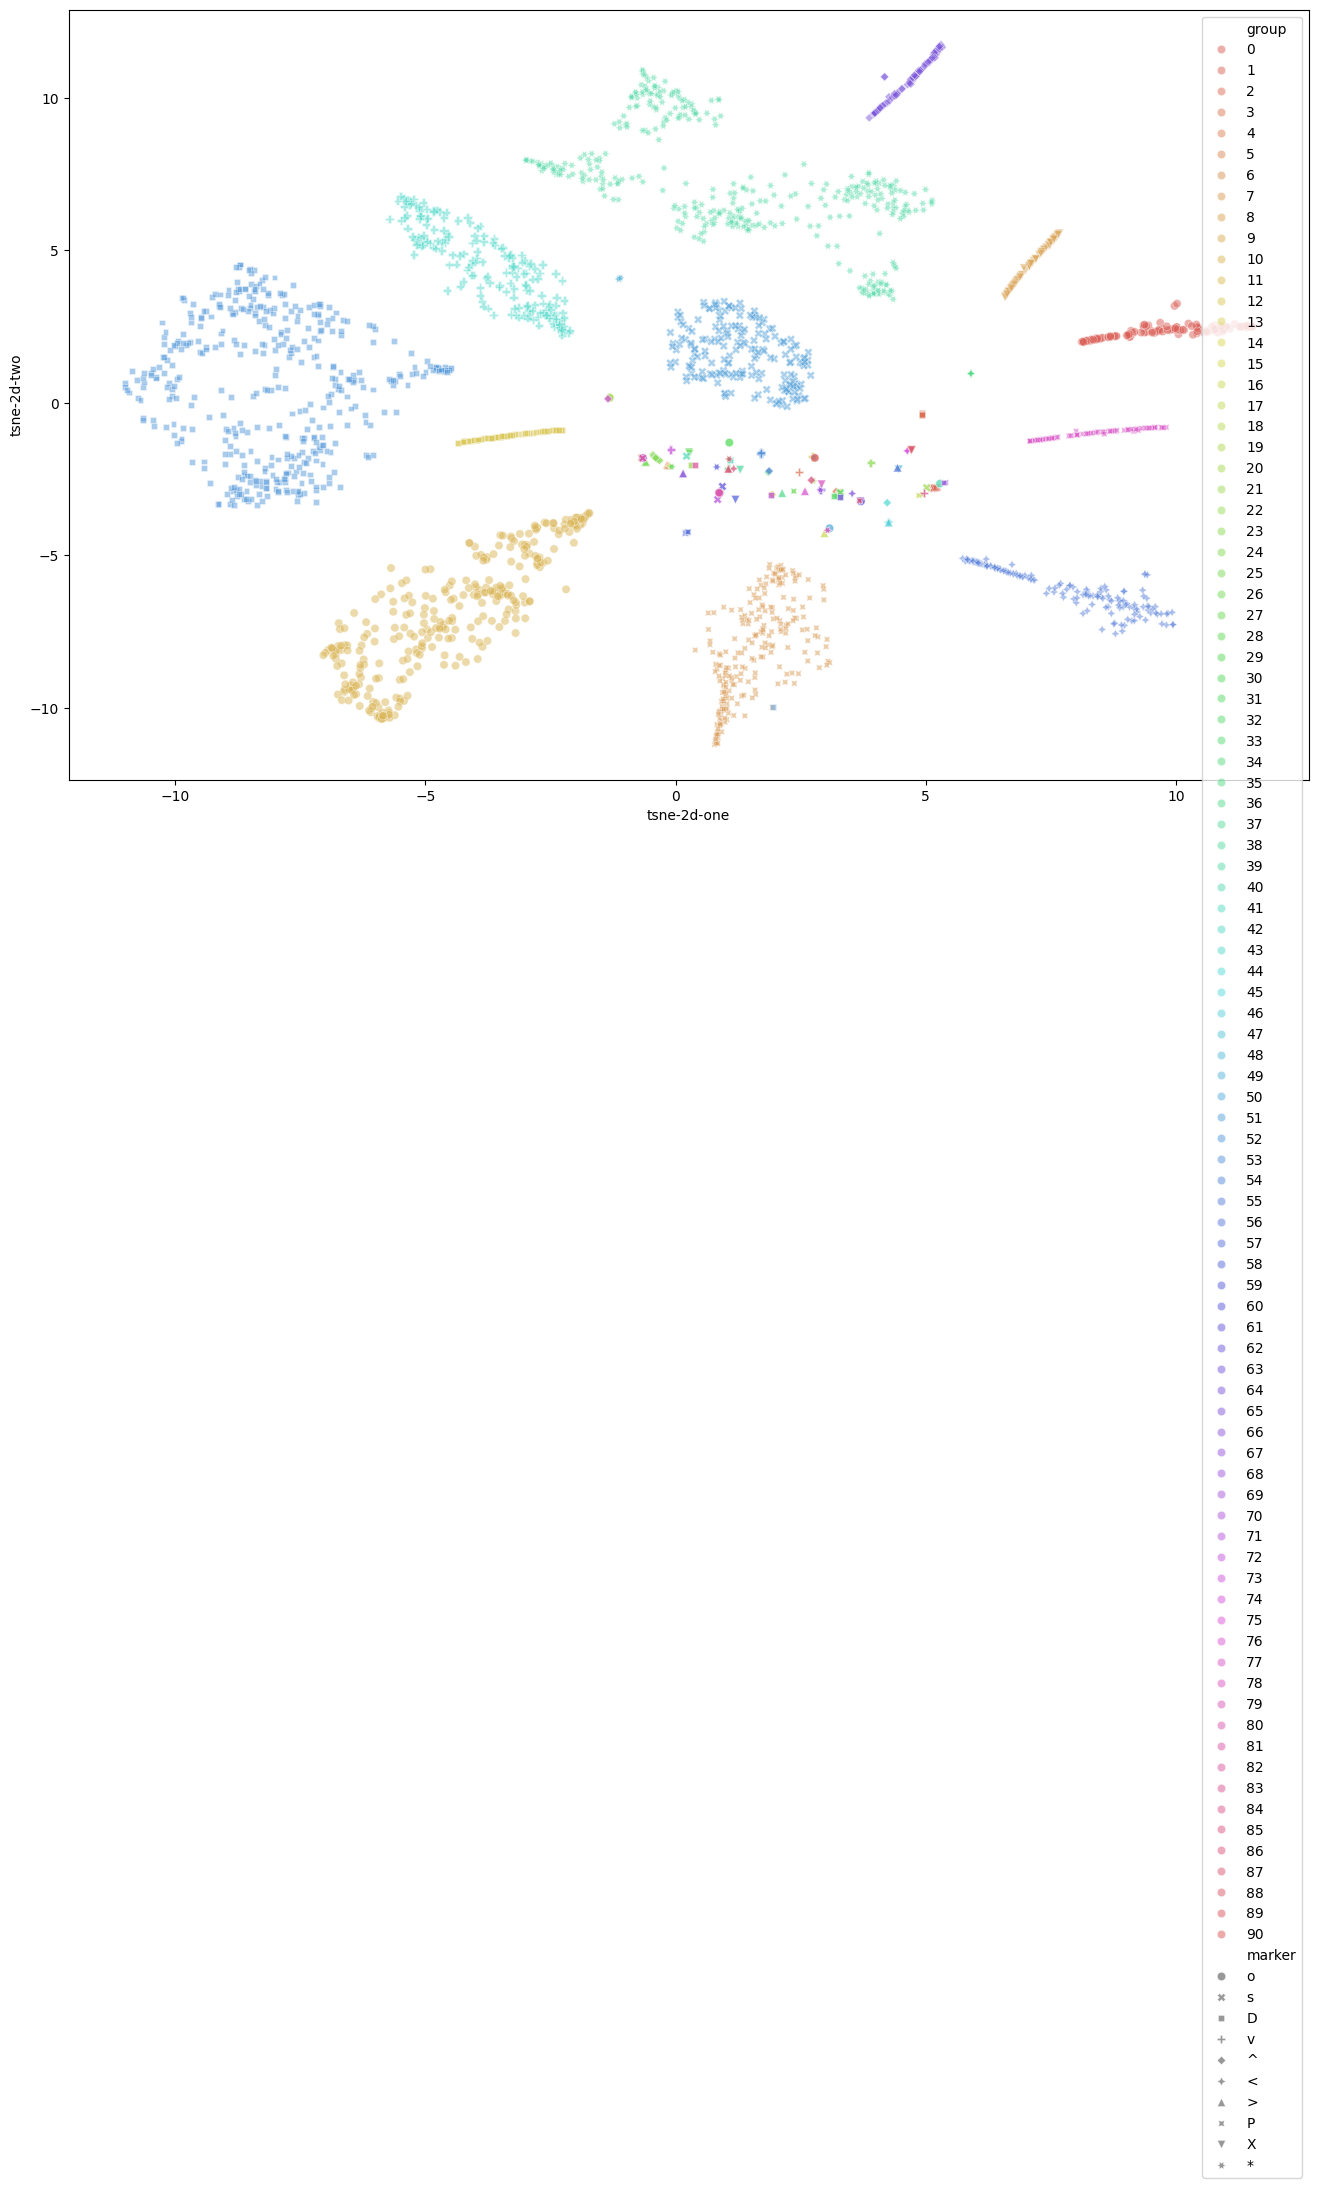

In [54]:
# grace sbm
model_name = "grace"
augmentation_name = "sbm"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 15.10it/s]


split time:  0.07  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976
already communities


100%|██████████| 500/500 [07:32<00:00,  1.10it/s]


pretrain loss:  [6.95, 6.95, 6.95, 6.94, 6.94]
pretrain time: 452.88 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.094s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.539852
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.974304
[t-SNE] KL divergence after 300 iterations: 1.307824


100%|██████████| 100/100 [01:05<00:00,  1.54it/s]


train loss:  [0.53, 0.48, 0.46, 0.45, 0.44, 0.43, 0.42, 0.42, 0.41, 0.41]
train time: 65.03 s
Hits@10:  val: 30.33%, test: 24.05%
Hits@20:  val: 50.00%, test: 33.78%
Hits@50:  val: 90.37%, test: 67.14%
Hits@100:  val: 97.95%, test: 97.75%
ROCAUC:  val: 94.31%, test: 95.60%
AP:  val: 92.31%, test: 94.22%


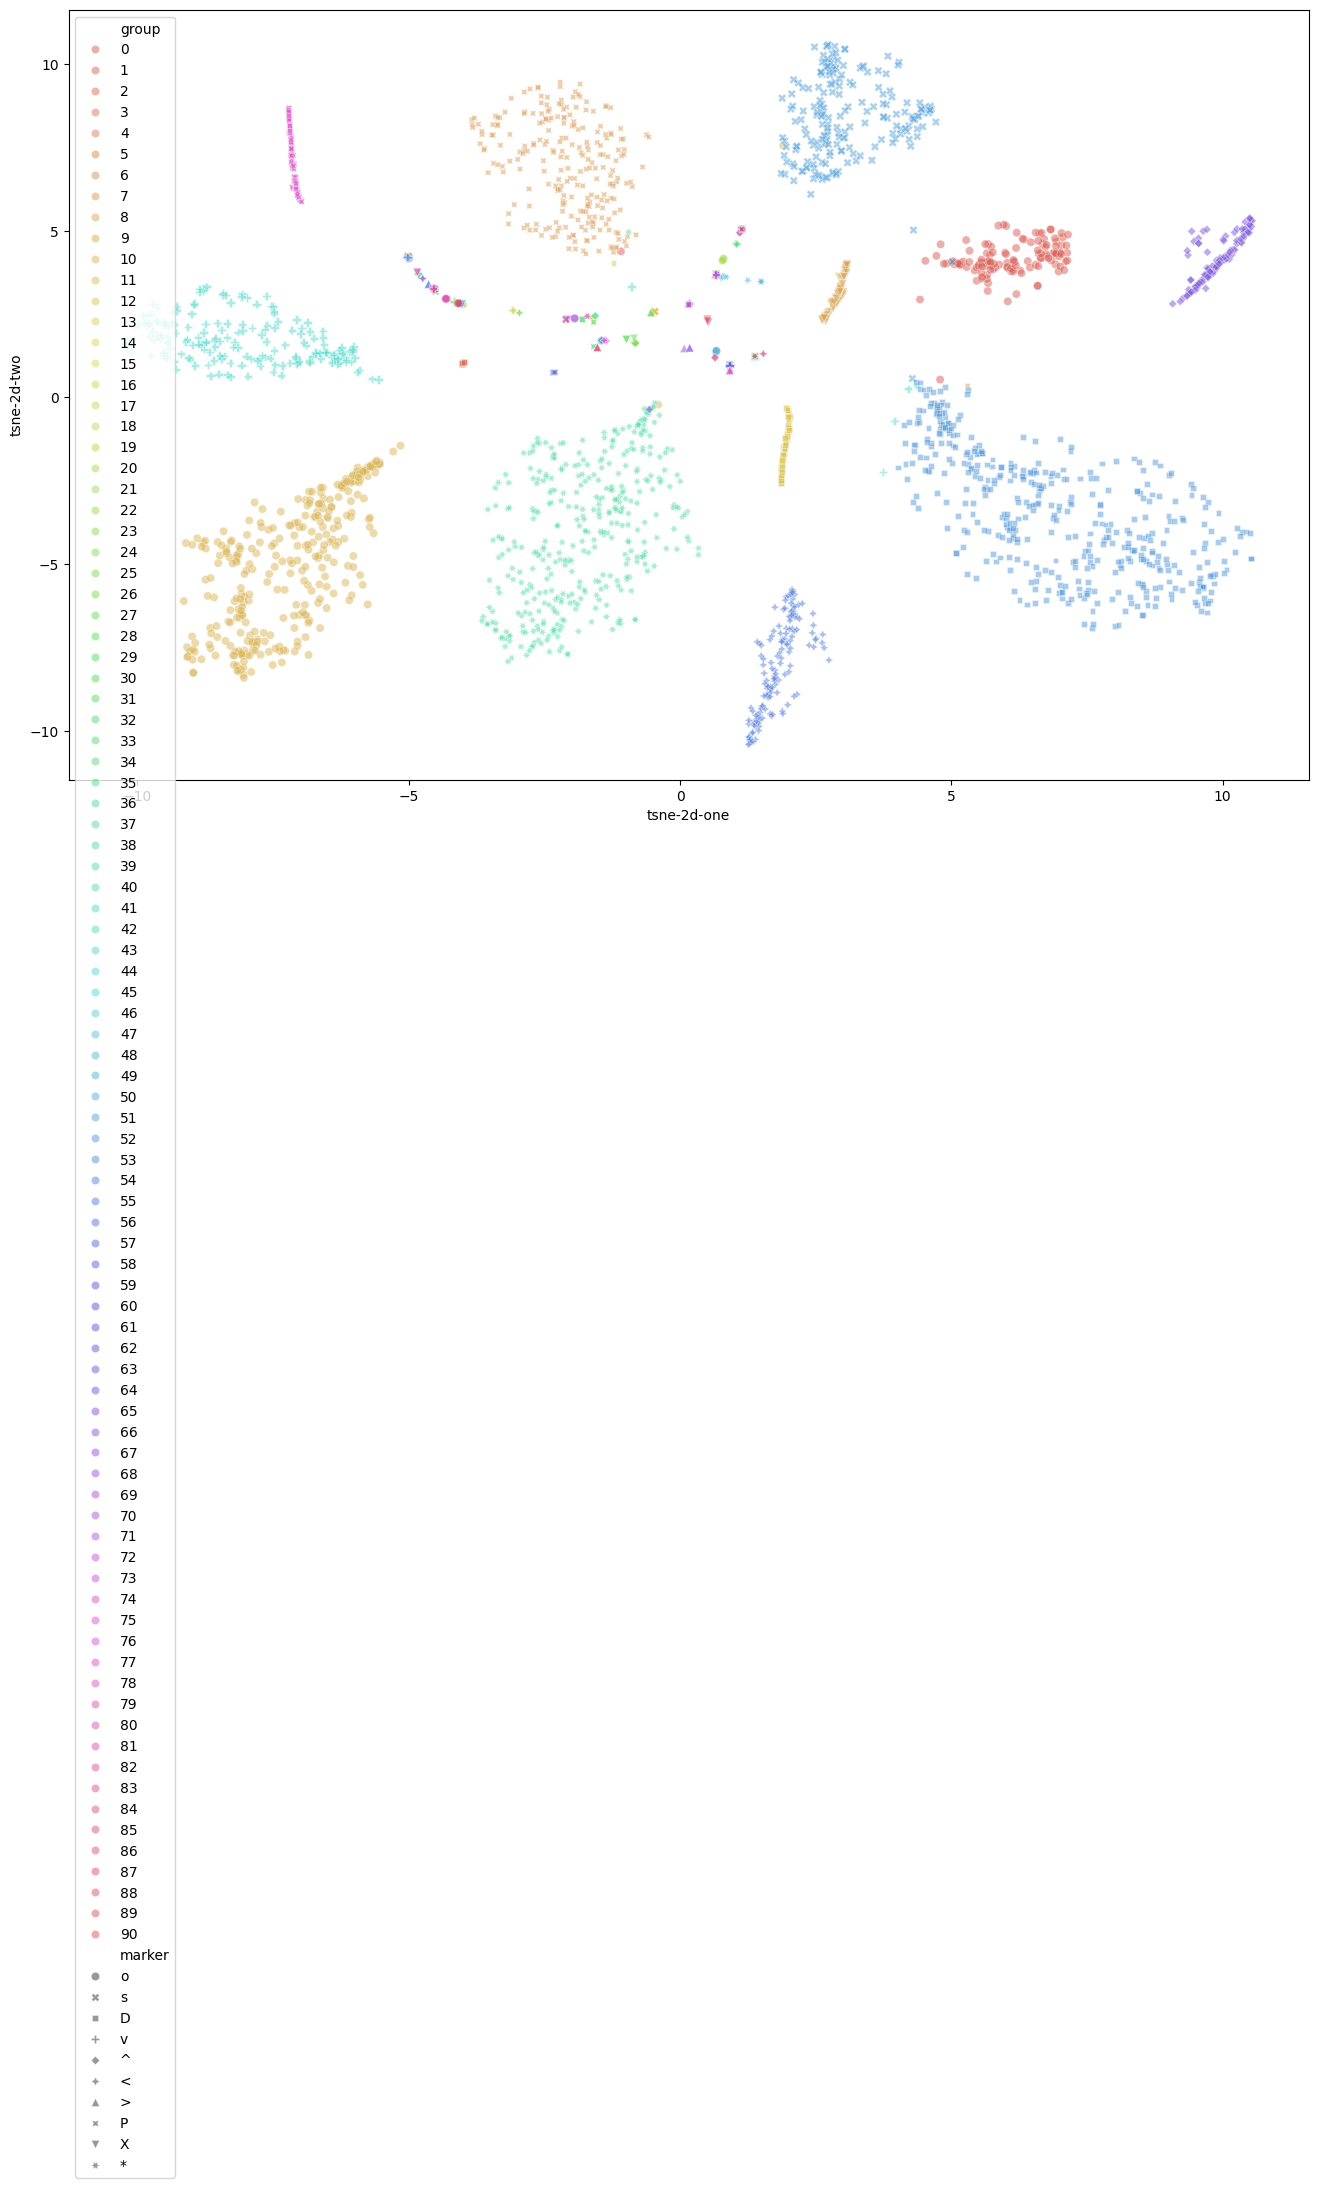

In [55]:
# grace sbm2
model_name = "grace"
augmentation_name = "sbm2"
simple_run(model_name, augmentation_name, ["synthetic_3"])

# Â vs 2 Â vs Â extended

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 27.73it/s]


split time:  0.04  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


100%|██████████| 500/500 [00:14<00:00, 35.42it/s]


pretrain loss:  [6.73, 6.71, 6.71, 6.71, 6.7]
pretrain time: 14.12 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.083s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.748346
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.537323
[t-SNE] KL divergence after 300 iterations: 1.627683


100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


train loss:  [0.3, 0.22, 0.19, 0.17, 0.16, 0.16, 0.15, 0.15, 0.14, 0.14]
train time: 64.94 s
Hits@10:  val: 21.52%, test: 24.26%
Hits@20:  val: 36.27%, test: 35.31%
Hits@50:  val: 51.64%, test: 52.10%
Hits@100:  val: 61.89%, test: 63.25%
ROCAUC:  val: 74.53%, test: 82.23%
AP:  val: 78.18%, test: 84.97%


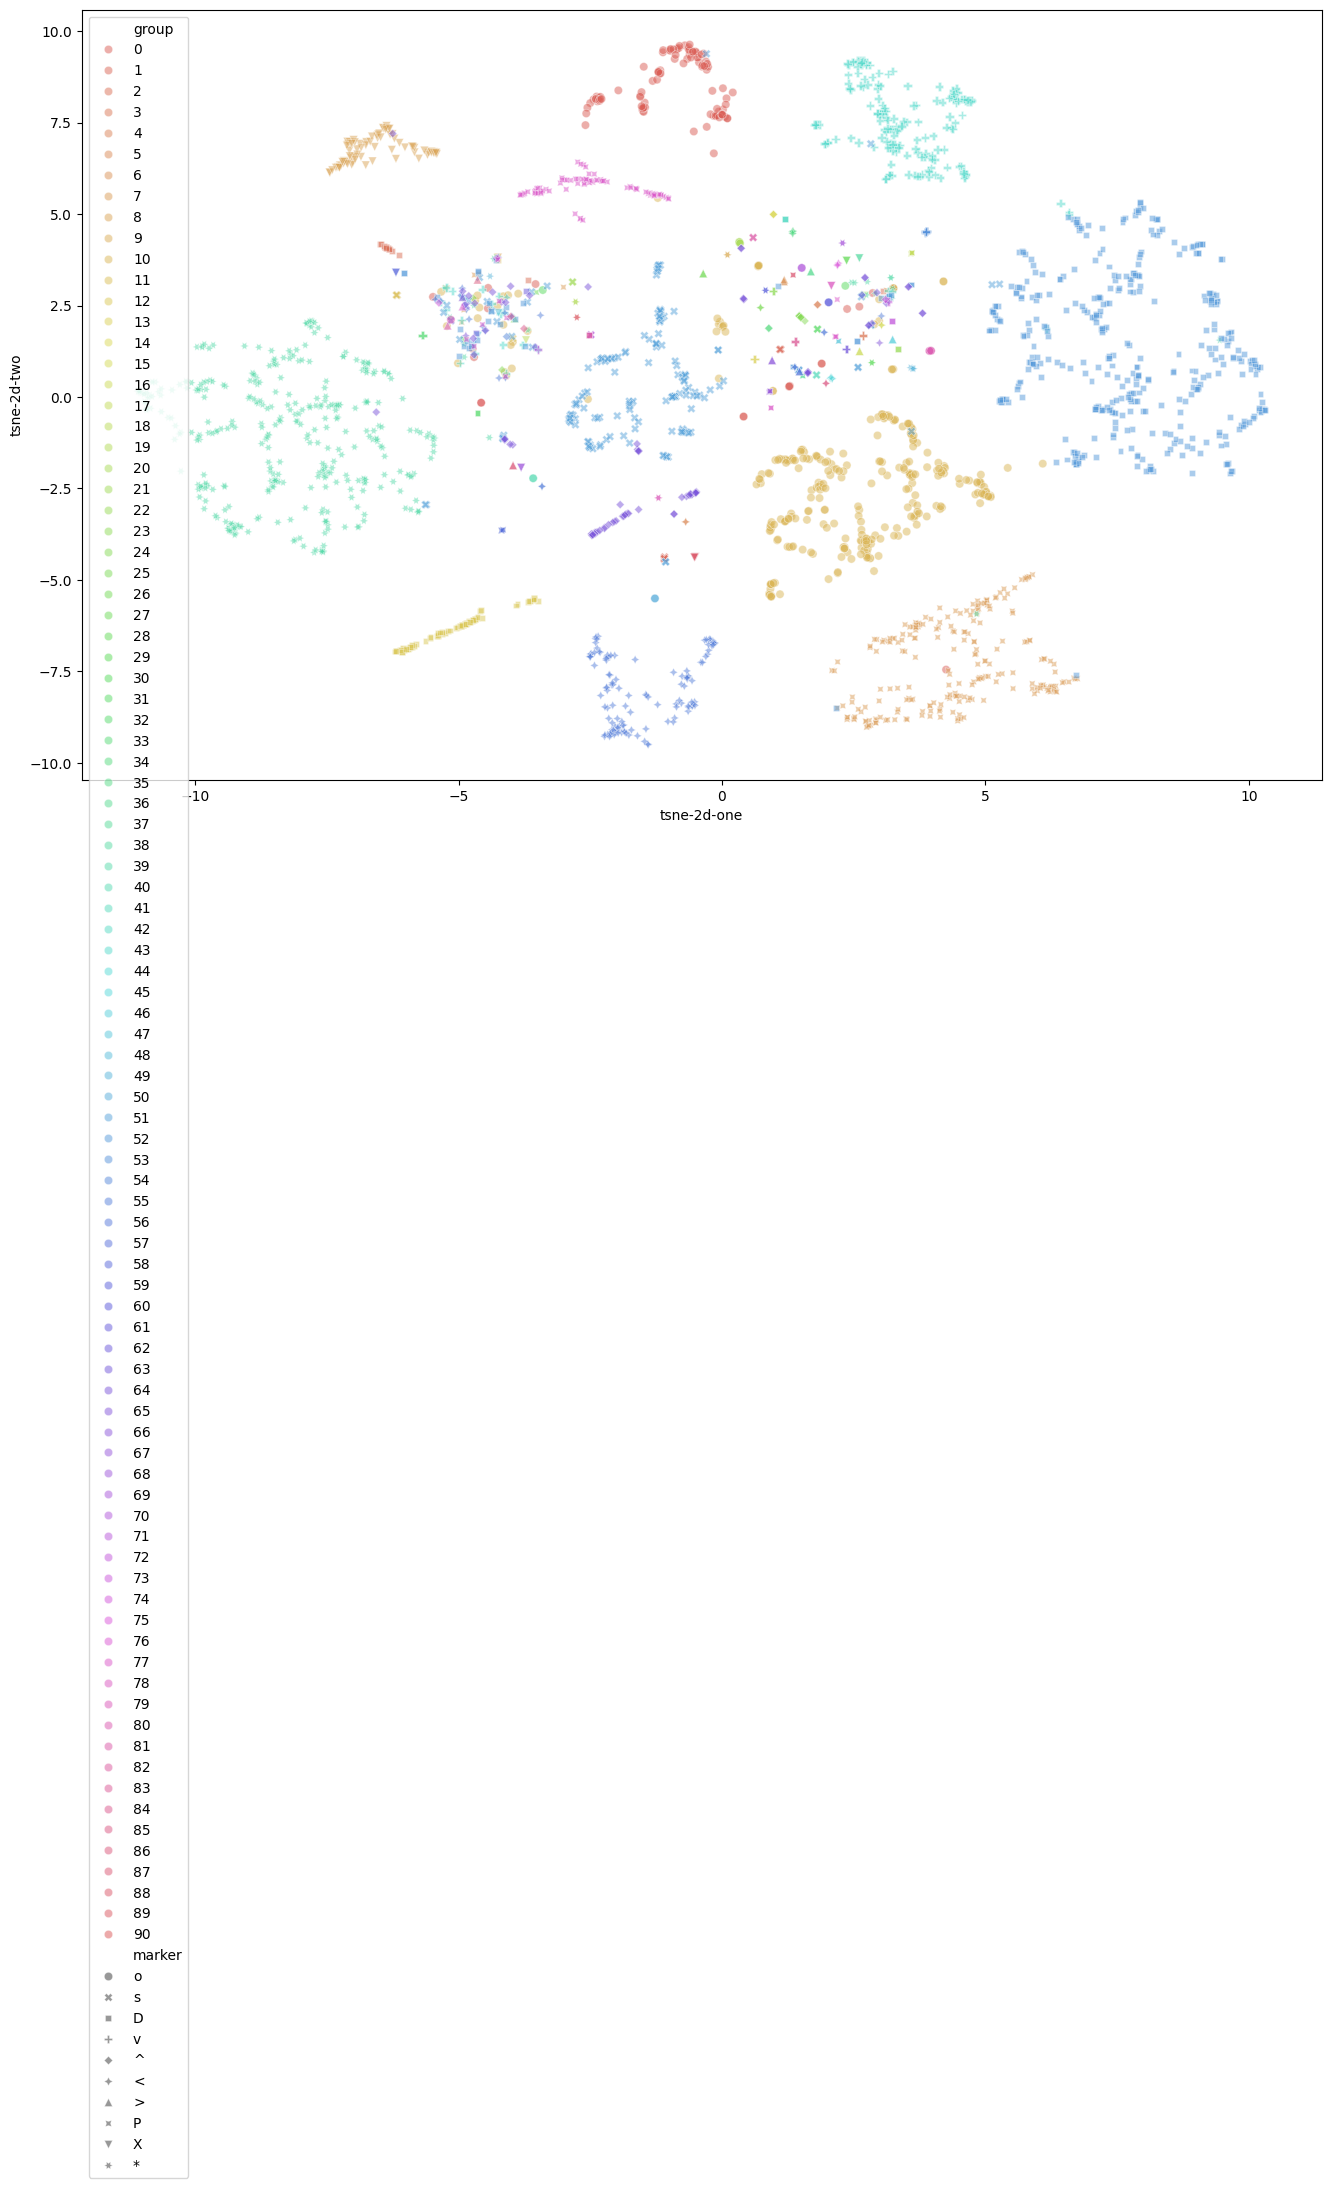

In [59]:
#random
model_name = "a2grace"
augmentation_name = "random"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 18.23it/s]


split time:  0.06  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


100%|██████████| 500/500 [00:17<00:00, 29.32it/s]


pretrain loss:  [6.73, 6.71, 6.71, 6.7, 6.7]
pretrain time: 17.05 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.099s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.749194
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.705833
[t-SNE] KL divergence after 300 iterations: 1.635903


100%|██████████| 100/100 [01:04<00:00,  1.56it/s]


train loss:  [0.3, 0.22, 0.19, 0.17, 0.16, 0.16, 0.15, 0.15, 0.14, 0.14]
train time: 64.09 s
Hits@10:  val: 21.93%, test: 24.46%
Hits@20:  val: 36.48%, test: 33.88%
Hits@50:  val: 50.00%, test: 51.79%
Hits@100:  val: 60.86%, test: 61.62%
ROCAUC:  val: 74.20%, test: 81.75%
AP:  val: 78.19%, test: 84.64%


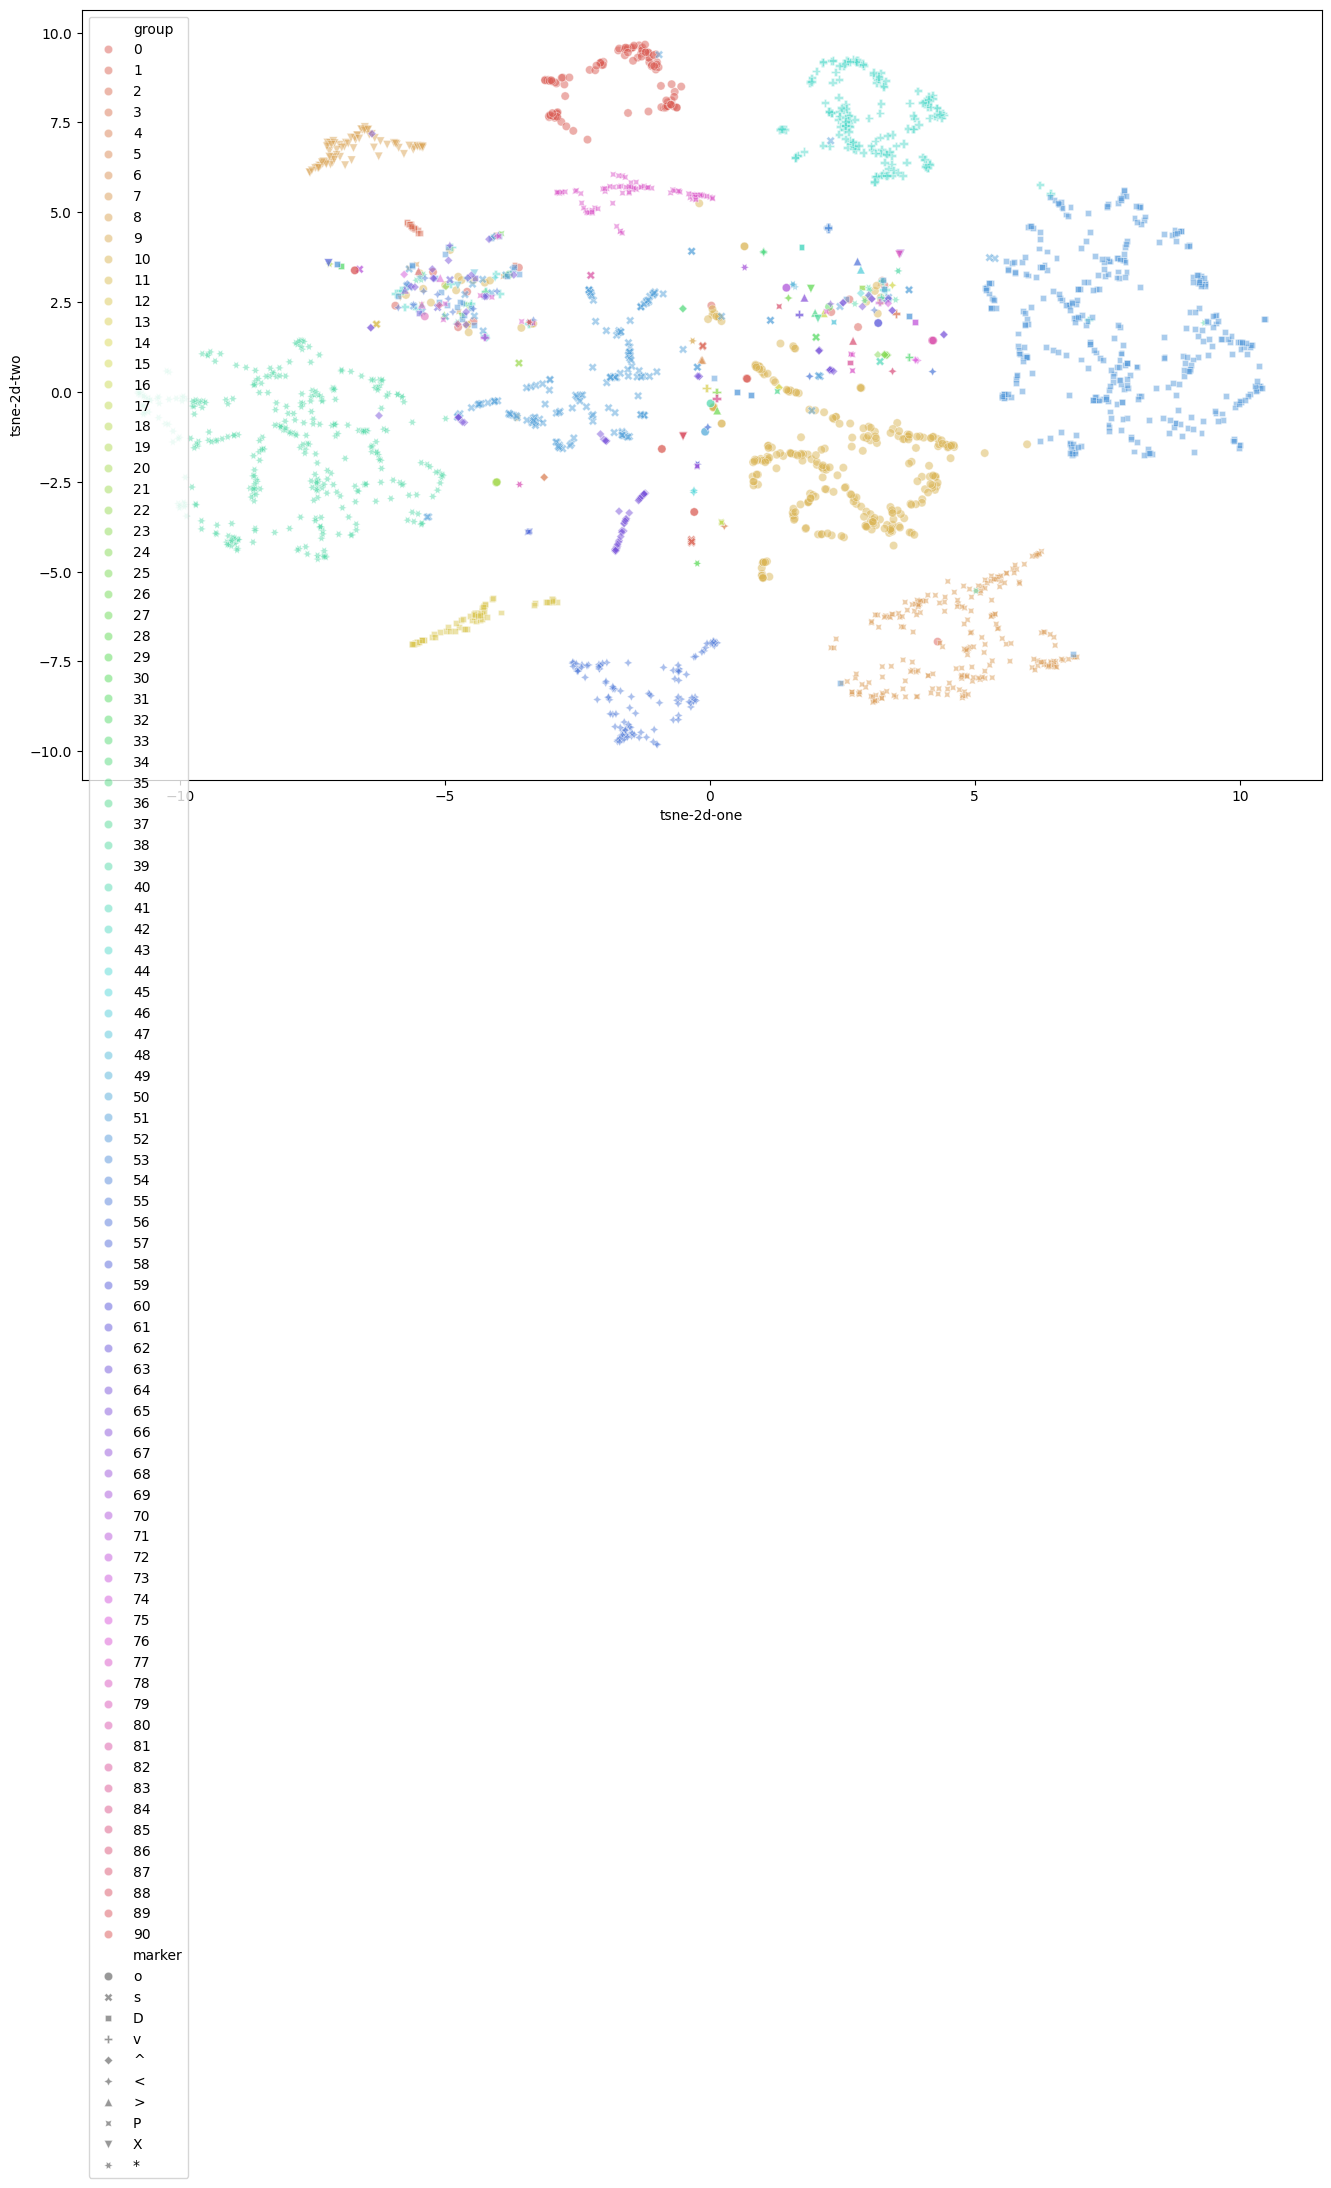

In [57]:
#random
model_name = "a2grace"
augmentation_name = "random"
simple_run(model_name, augmentation_name, ["synthetic_3"])

In [ ]:
#random
model_name = "extagrace"
augmentation_name = "random"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 29.06it/s]


split time:  0.04  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


 28%|██▊       | 141/500 [09:26<27:29,  4.59s/it]

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00,  2.15it/s]


split time:  0.47  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


100%|██████████| 500/500 [31:04<00:00,  3.73s/it]


pretrain loss:  [7.05, 7.0, 6.96, 6.96, 6.94]
pretrain time: 1864.23 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.113s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 1.311360
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.730259
[t-SNE] KL divergence after 300 iterations: 1.266571


100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


train loss:  [0.37, 0.32, 0.29, 0.27, 0.26, 0.26, 0.25, 0.24, 0.24, 0.24]
train time: 64.61 s
Hits@10:  val: 33.20%, test: 16.68%
Hits@20:  val: 48.16%, test: 30.60%
Hits@50:  val: 78.07%, test: 60.70%
Hits@100:  val: 83.20%, test: 81.17%
ROCAUC:  val: 88.13%, test: 89.85%
AP:  val: 88.64%, test: 89.26%


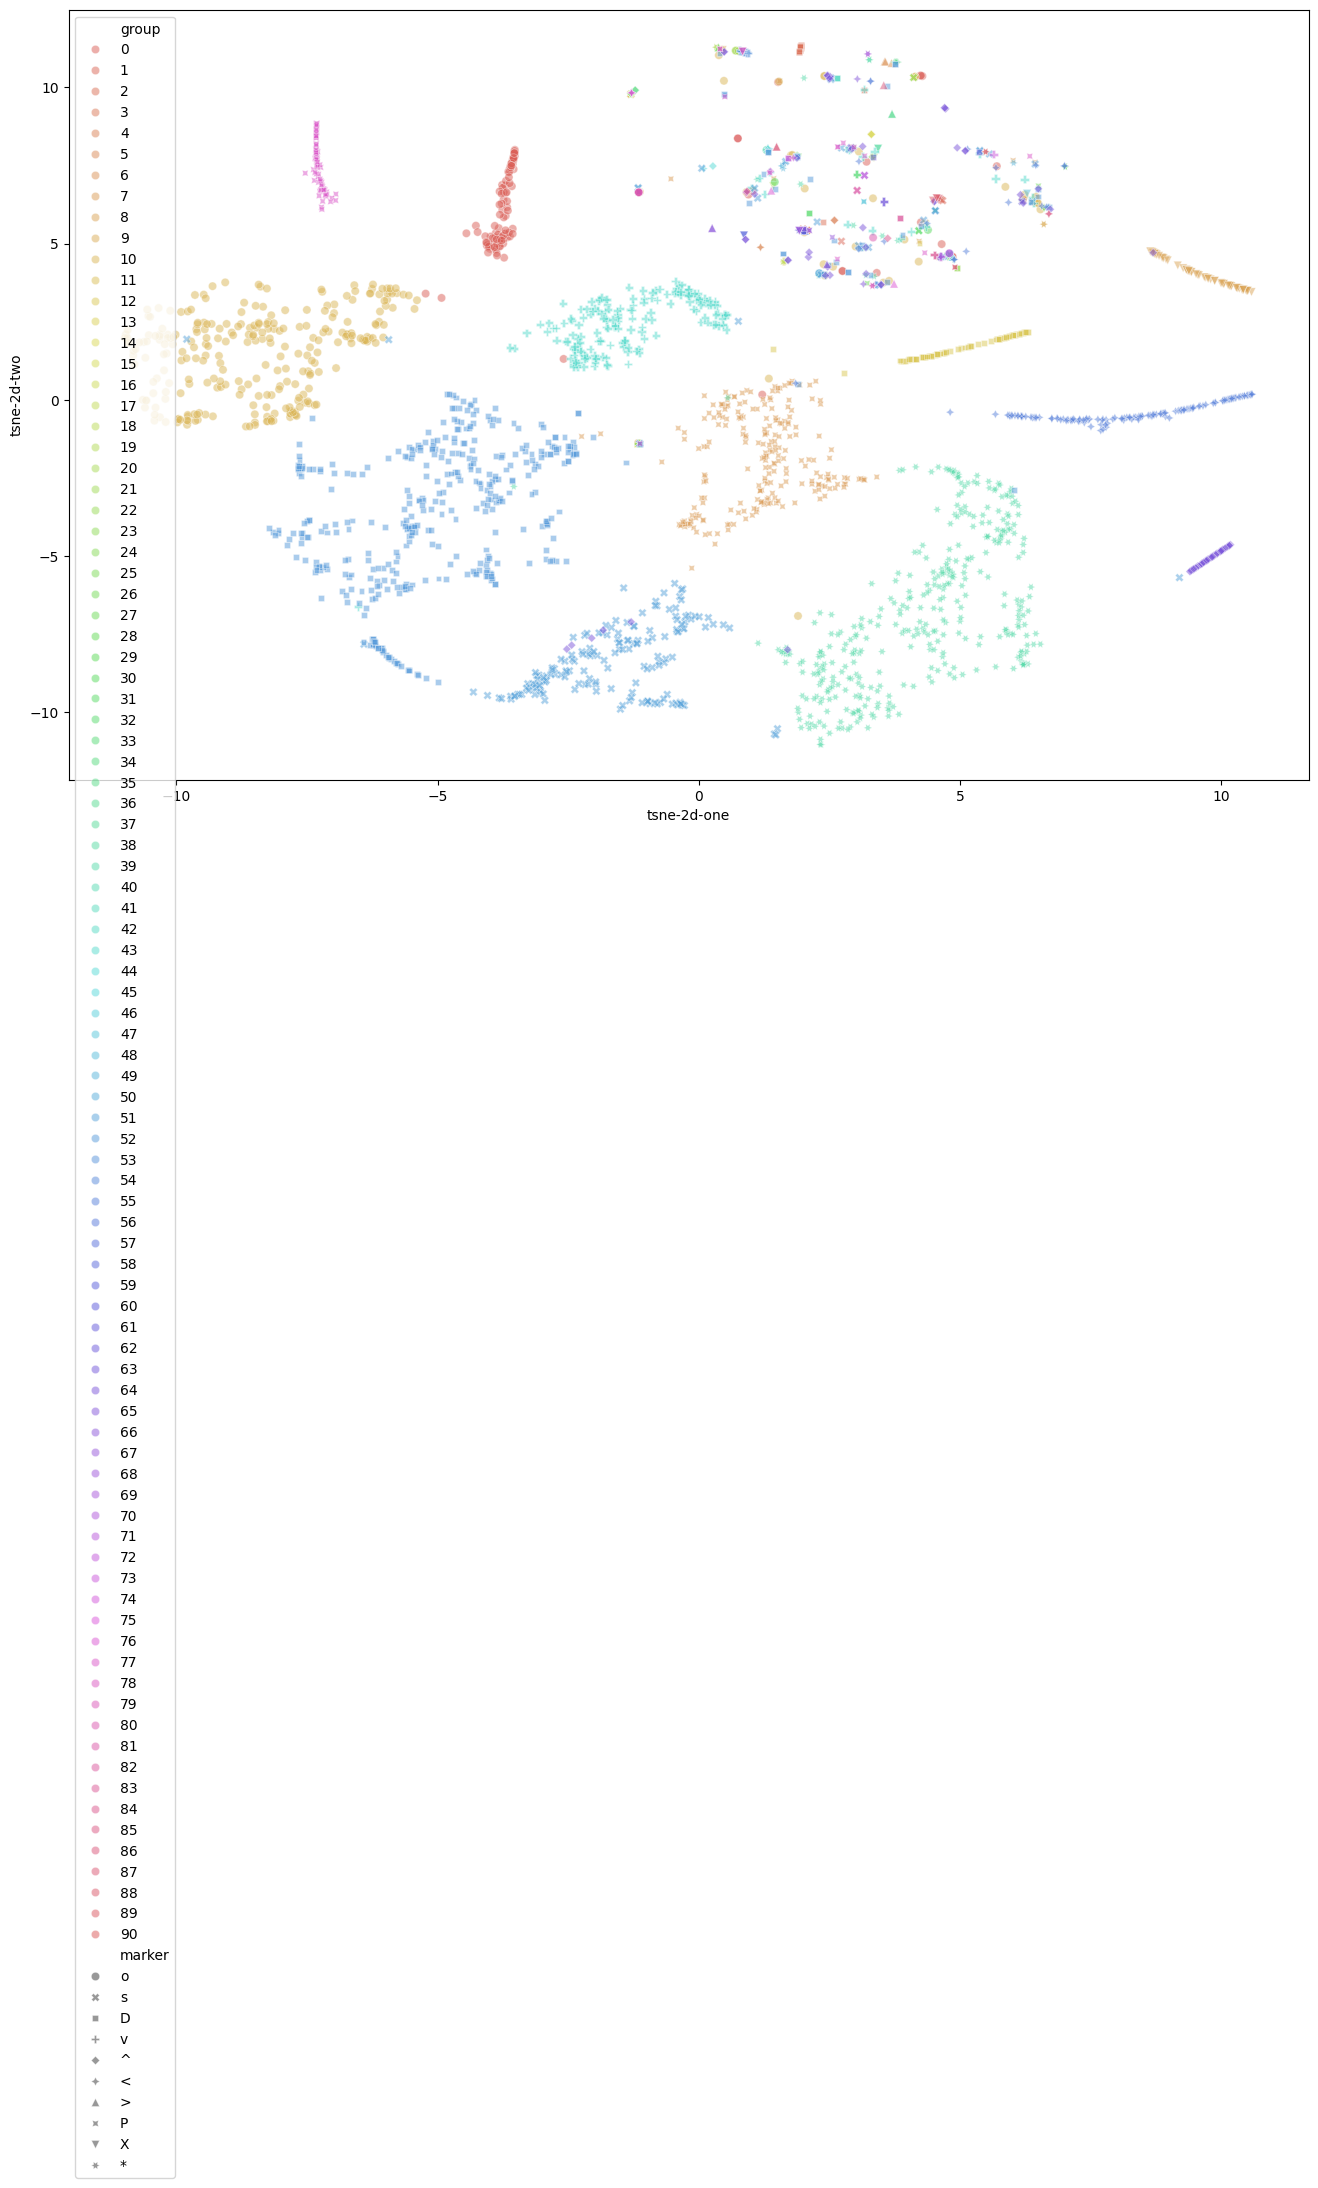

In [58]:
#sbm
model_name = "agrace"
augmentation_name = "sbm"
simple_run(model_name, augmentation_name, ["synthetic_3"])

In [ ]:
#sbm
model_name = "a2grace"
augmentation_name = "sbm"
simple_run(model_name, augmentation_name, ["synthetic_3"])

In [ ]:
#sbm
model_name = "extagrace"
augmentation_name = "sbm"
simple_run(model_name, augmentation_name, ["synthetic_3"])

# Link-Grace

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 23.25it/s]


split time:  0.04  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976


100%|██████████| 500/500 [00:18<00:00, 27.61it/s]


pretrain loss:  [8.45, 8.14, 7.91, 7.77, 7.68, 7.61, 7.56, 7.51, 7.47, 7.44, 7.4, 7.37, 7.34, 7.31, 7.29, 7.27, 7.25, 7.23, 7.22, 7.2, 7.18, 7.17, 7.16, 7.14, 7.13, 7.12, 7.11, 7.1, 7.09, 7.08, 7.07, 7.07, 7.06, 7.05, 7.04, 7.04, 7.03, 7.02, 7.02, 7.01, 7.0, 7.0, 6.99, 6.99, 6.98, 6.98, 6.97, 6.97, 6.97, 6.96]
pretrain time: 18.11 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.094s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 0.905200
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.631836
[t-SNE] KL divergence after 300 iterations: 1.360406


100%|██████████| 100/100 [01:03<00:00,  1.57it/s]


train loss:  [0.43, 0.37, 0.34, 0.33, 0.32, 0.31, 0.3, 0.29, 0.29, 0.28]
train time: 63.61 s
Hits@10:  val: 25.82%, test: 22.01%
Hits@20:  val: 36.48%, test: 33.88%
Hits@50:  val: 70.90%, test: 55.78%
Hits@100:  val: 79.51%, test: 76.87%
ROCAUC:  val: 84.21%, test: 87.74%
AP:  val: 85.19%, test: 88.60%


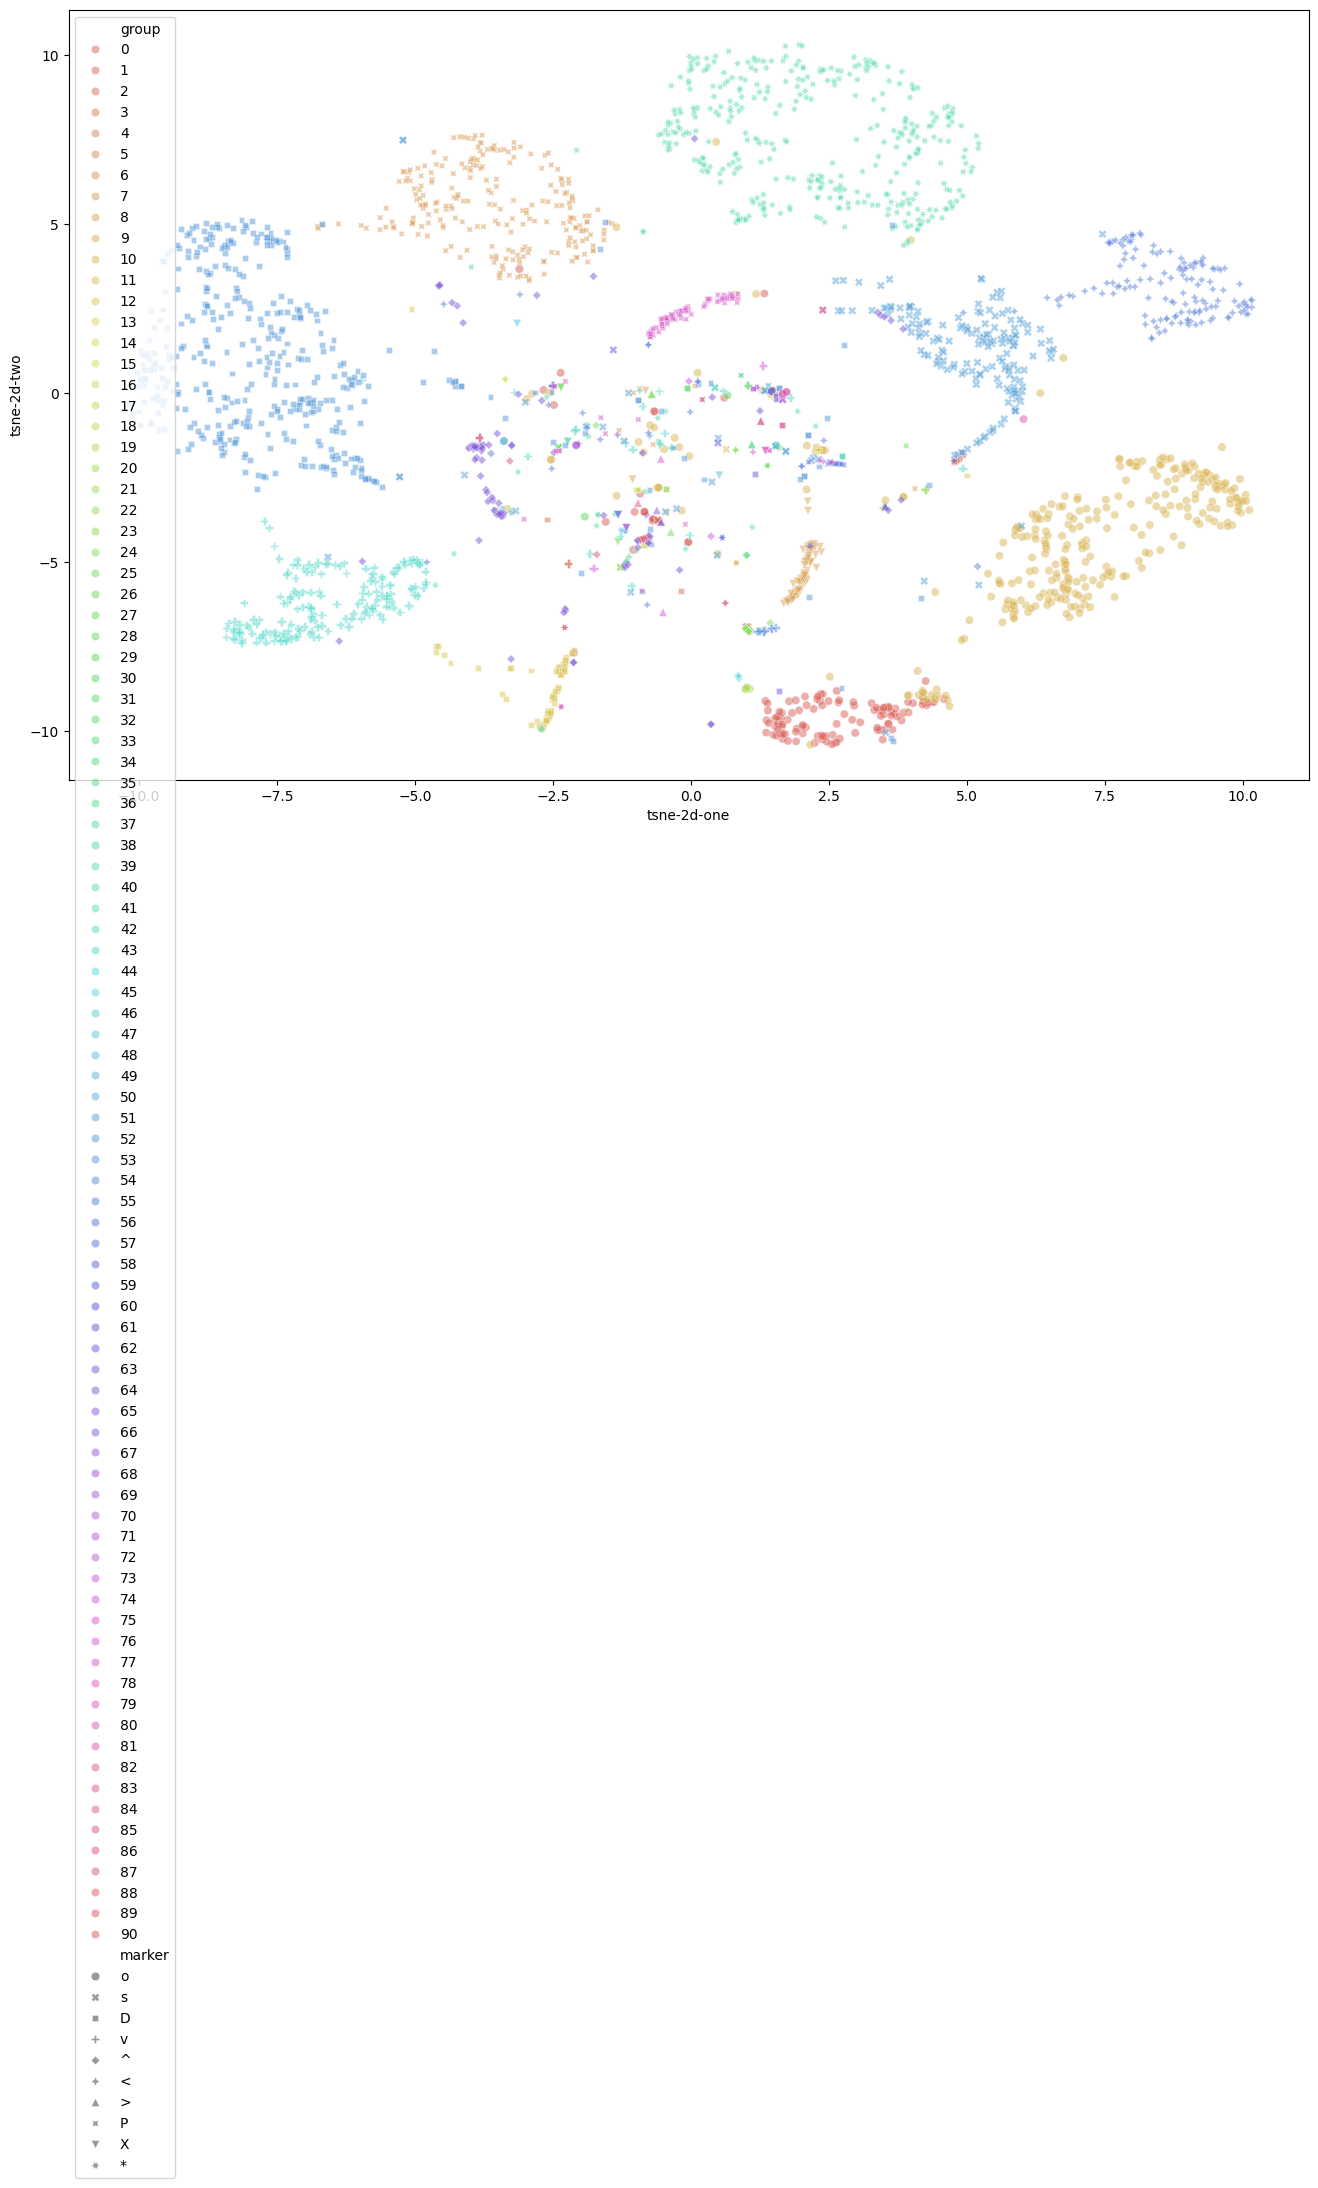

In [5]:
#sbm
model_name = "lnewgrace"
augmentation_name = "random"
simple_run(model_name, augmentation_name, ["synthetic_3"])

....synthetic_3....
1 split from the dataset synthetic_3


100%|██████████| 1/1 [00:00<00:00, 14.92it/s]


split time:  0.07  s
dataset split 
train edge 3423
valid edge 488
valid edge_neg 488
test edge 977
test edge_neg 976
already communities


100%|██████████| 500/500 [03:54<00:00,  2.13it/s]


pretrain loss:  [6.39, 6.13, 5.97, 5.83, 5.73, 5.65, 5.59, 5.54, 5.49, 5.45, 5.41, 5.38, 5.35, 5.32, 5.29, 5.27, 5.25, 5.23, 5.21, 5.19, 5.18, 5.17, 5.15, 5.13, 5.12, 5.11, 5.1, 5.08, 5.07, 5.07, 5.06, 5.05, 5.04, 5.03, 5.02, 5.01, 5.01, 5.0, 4.99, 4.98, 4.98, 4.97, 4.96, 4.96, 4.95, 4.95, 4.94, 4.94, 4.93, 4.93]
pretrain time: 234.38 s
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2708 samples in 0.001s...
[t-SNE] Computed neighbors for 2708 samples in 0.103s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2708
[t-SNE] Computed conditional probabilities for sample 2000 / 2708
[t-SNE] Computed conditional probabilities for sample 2708 / 2708
[t-SNE] Mean sigma: 1.467427
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.837772
[t-SNE] KL divergence after 300 iterations: 1.524812


100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


train loss:  [0.61, 0.57, 0.55, 0.53, 0.52, 0.51, 0.51, 0.5, 0.49, 0.48]
train time: 64.53 s
Hits@10:  val: 32.17%, test: 30.91%
Hits@20:  val: 51.64%, test: 39.00%
Hits@50:  val: 80.12%, test: 61.21%
Hits@100:  val: 86.89%, test: 83.52%
ROCAUC:  val: 88.23%, test: 90.13%
AP:  val: 88.82%, test: 90.82%


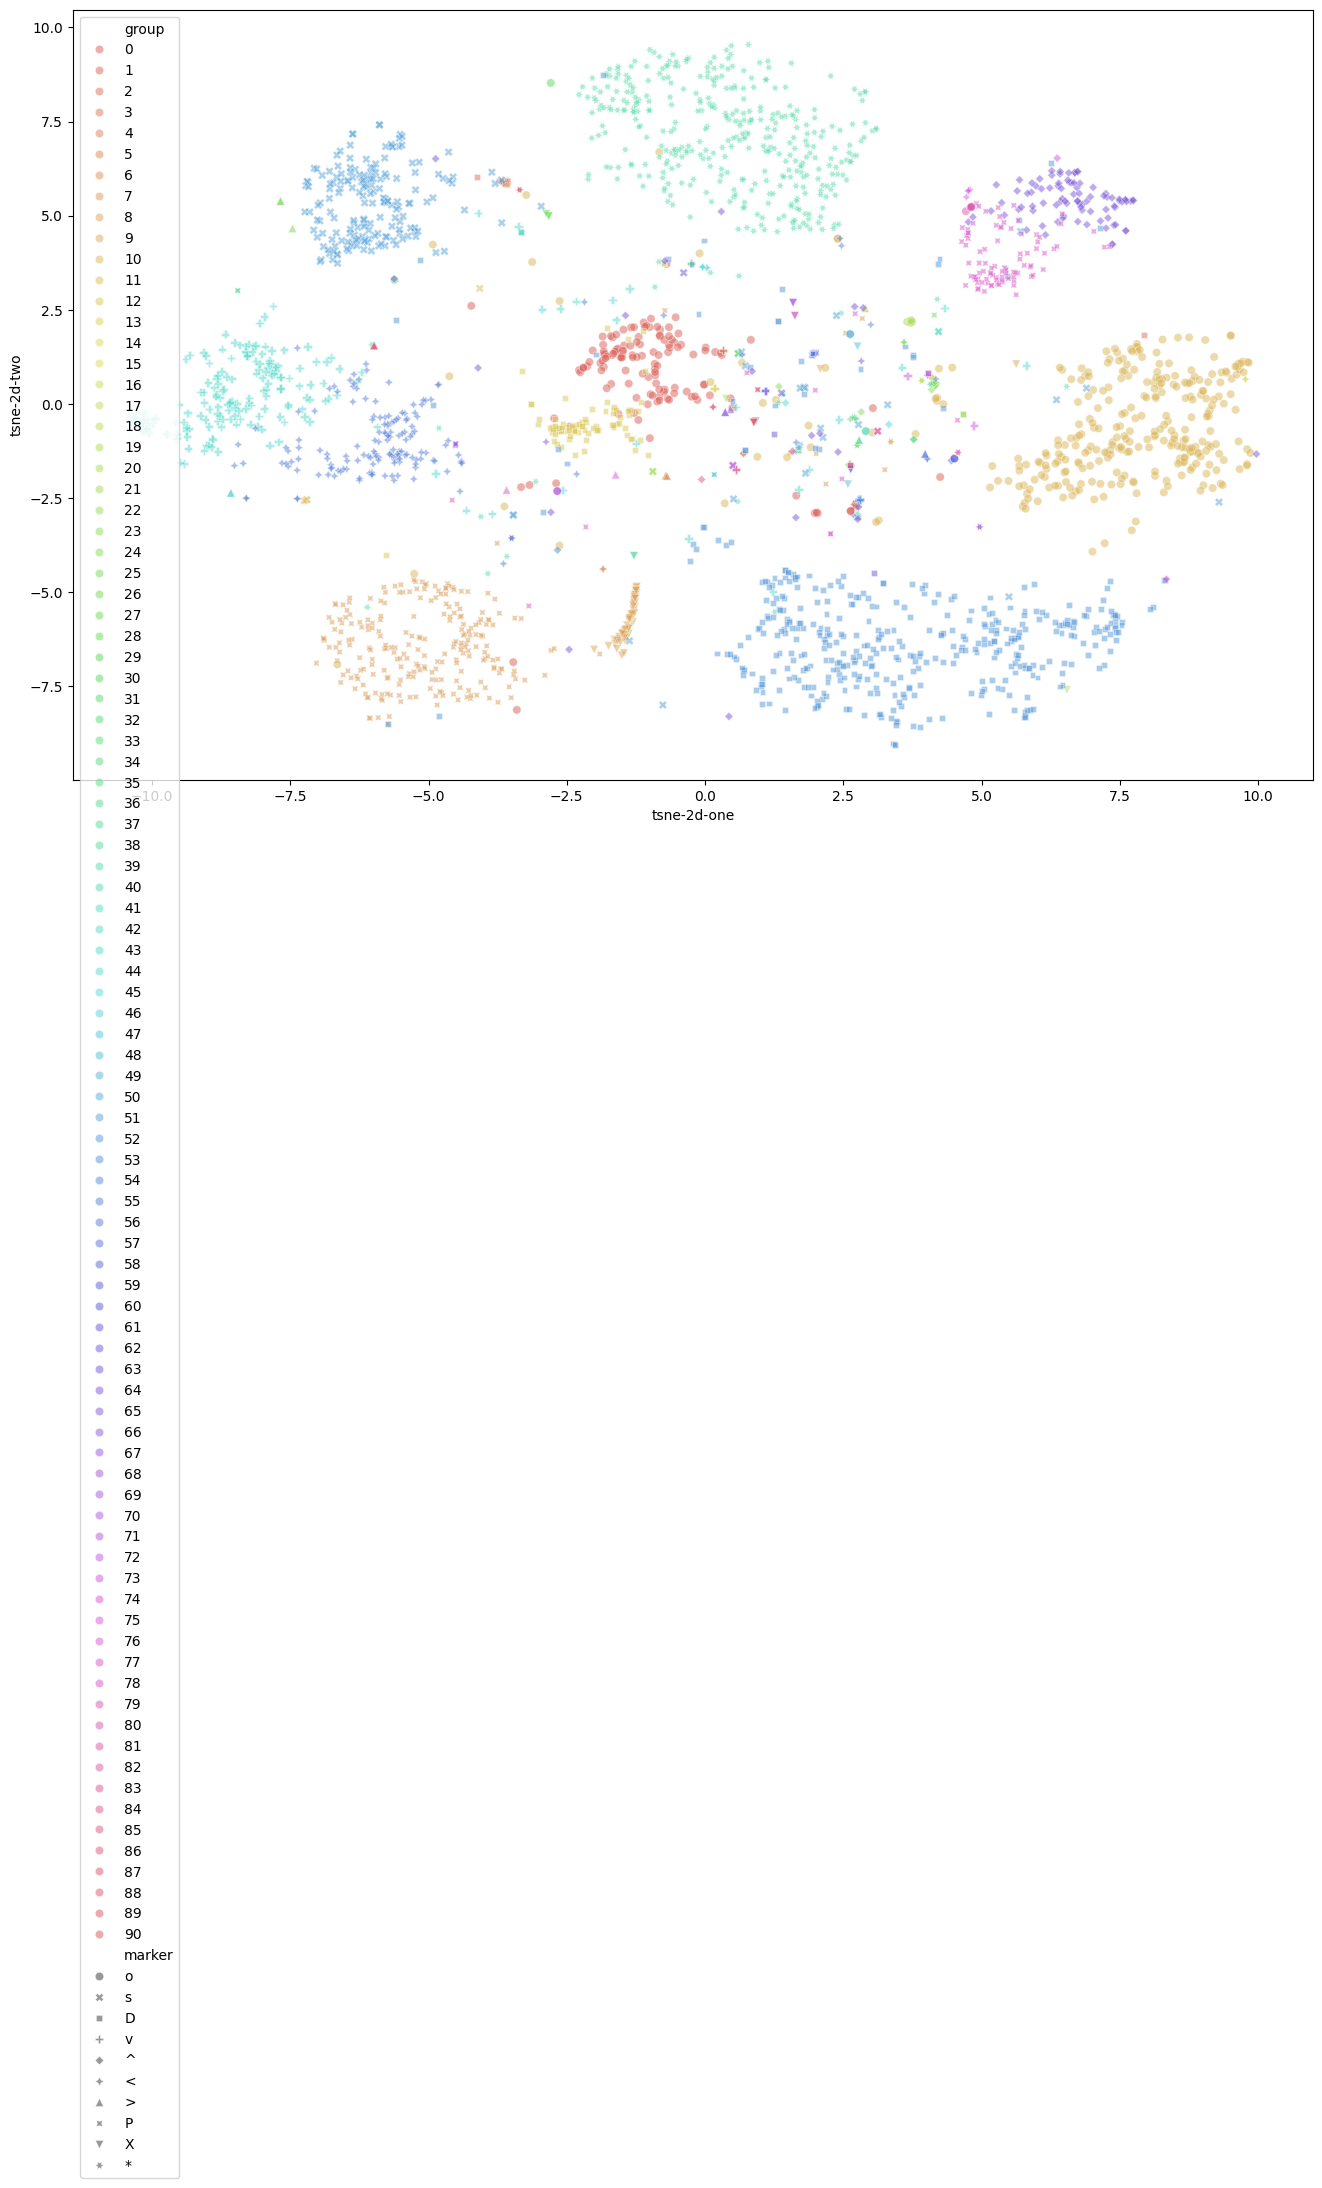

In [7]:
#sbm
model_name = "lnewgrace"
augmentation_name = "sbm"
simple_run(model_name, augmentation_name, ["synthetic_3"])